# Packages

In [1]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D

# ncon function
This implementation of the $\textbf{ncon}$ function is sourced from https://www.tensors.net/code. The underlying contraction algorithm is described in the paper https://arxiv.org/abs/1402.0939v3.

In [2]:
# ncon network contractor
# by Glen Evenbly (c) for www.tensors.net, (v1.2) - last modified 6/2020

# ncon.py
import numpy as np
from typing import List, Union, Tuple, Optional


def ncon(tensors: List[np.ndarray],
         connects: List[Union[List[int], Tuple[int]]],
         con_order: Optional[Union[List[int], str]] = None,
         check_network: Optional[bool] = True,
         which_env: Optional[int] = 0):
  """
  Network CONtractor: contracts a tensor network of N tensors via a sequence
  of (N-1) tensordot operations. More detailed instructions and examples can
  be found at: https://arxiv.org/abs/1402.0939.
  Args:
    tensors: list of the tensors in the network.
    connects: length-N list of lists (or tuples) specifying the network
      connections. The jth entry of the ith list in connects labels the edge
      connected to the jth index of the ith tensor. Labels should be positive
      integers for internal indices and negative integers for free indices.
    con_order: optional argument to specify the order for contracting the
      positive indices. Defaults to ascending order if omitted. Can also be
      set at "greedy" or "full" to call a solver to automatically determine
      the order.
    check_network: if true then the input network is checked for consistency;
      this can catch many common user mistakes for defining networks.
    which_env: if provided, ncon will produce the environment of the requested
      tensor (i.e. the network given by removing the specified tensor from
      the original network). Only valid for networks with no open indices.
  Returns:
    Union[np.ndarray,float]: the result of the network contraction; an
      np.ndarray if the network contained open indices, otherwise a scalar.
  """
  num_tensors = len(tensors)
  tensor_list = [tensors[ele] for ele in range(num_tensors)]
  connect_list = [np.array(connects[ele]) for ele in range(num_tensors)]

  # generate contraction order if necessary
  flat_connect = np.concatenate(connect_list)
  if con_order is None:
    con_order = np.unique(flat_connect[flat_connect > 0])
  else:
    con_order = np.array(con_order)

  # check inputs if enabled
  if check_network:
    dims_list = [list(tensor.shape) for tensor in tensor_list]
    check_inputs(connect_list, flat_connect, dims_list, con_order)

  # do all partial traces
  for ele in range(len(tensor_list)):
    num_cont = len(connect_list[ele]) - len(np.unique(connect_list[ele]))
    if num_cont > 0:
      tensor_list[ele], connect_list[ele], cont_ind = partial_trace(
          tensor_list[ele], connect_list[ele])
      con_order = np.delete(
          con_order,
          np.intersect1d(con_order, cont_ind, return_indices=True)[1])

  # do all binary contractions
  while len(con_order) > 0:
    # identify tensors to be contracted
    cont_ind = con_order[0]
    locs = [
        ele for ele in range(len(connect_list))
        if sum(connect_list[ele] == cont_ind) > 0
    ]

    # do binary contraction
    cont_many, A_cont, B_cont = np.intersect1d(
        connect_list[locs[0]],
        connect_list[locs[1]],
        assume_unique=True,
        return_indices=True)
    if np.size(tensor_list[locs[0]]) < np.size(tensor_list[locs[1]]):
      ind_order = np.argsort(A_cont)
    else:
      ind_order = np.argsort(B_cont)

    tensor_list.append(
        np.tensordot(
            tensor_list[locs[0]],
            tensor_list[locs[1]],
            axes=(A_cont[ind_order], B_cont[ind_order])))
    connect_list.append(
        np.append(
            np.delete(connect_list[locs[0]], A_cont),
            np.delete(connect_list[locs[1]], B_cont)))

    # remove contracted tensors from list and update con_order
    del tensor_list[locs[1]]
    del tensor_list[locs[0]]
    del connect_list[locs[1]]
    del connect_list[locs[0]]
    con_order = np.delete(
        con_order,
        np.intersect1d(con_order, cont_many, return_indices=True)[1])

  # do all outer products
  while len(tensor_list) > 1:
    s1 = tensor_list[-2].shape
    s2 = tensor_list[-1].shape
    tensor_list[-2] = np.outer(tensor_list[-2].reshape(np.prod(s1)),
                               tensor_list[-1].reshape(np.prod(s2))).reshape(
                                   np.append(s1, s2))
    connect_list[-2] = np.append(connect_list[-2], connect_list[-1])
    del tensor_list[-1]
    del connect_list[-1]

  # do final permutation
  if len(connect_list[0]) > 0:
    return np.transpose(tensor_list[0], np.argsort(-connect_list[0]))
  else:
    return tensor_list[0].item()


def partial_trace(A, A_label):
  """ Partial trace on tensor A over repeated labels in A_label """

  num_cont = len(A_label) - len(np.unique(A_label))
  if num_cont > 0:
    dup_list = []
    for ele in np.unique(A_label):
      if sum(A_label == ele) > 1:
        dup_list.append([np.where(A_label == ele)[0]])

    cont_ind = np.array(dup_list).reshape(2 * num_cont, order='F')
    free_ind = np.delete(np.arange(len(A_label)), cont_ind)

    cont_dim = np.prod(np.array(A.shape)[cont_ind[:num_cont]])
    free_dim = np.array(A.shape)[free_ind]

    B_label = np.delete(A_label, cont_ind)
    cont_label = np.unique(A_label[cont_ind])
    B = np.zeros(np.prod(free_dim))
    A = A.transpose(np.append(free_ind, cont_ind)).reshape(
        np.prod(free_dim), cont_dim, cont_dim)
    for ip in range(cont_dim):
      B = B + A[:, ip, ip]

    return B.reshape(free_dim), B_label, cont_label

  else:
    return A, A_label, []


def check_inputs(connect_list, flat_connect, dims_list, con_order):
  """ Check consistancy of NCON inputs"""

  pos_ind = flat_connect[flat_connect > 0]
  neg_ind = flat_connect[flat_connect < 0]

  # check that lengths of lists match
  if len(dims_list) != len(connect_list):
    raise ValueError(
        ('mismatch between %i tensors given but %i index sublists given') %
        (len(dims_list), len(connect_list)))

  # check that tensors have the right number of indices
  for ele in range(len(dims_list)):
    if len(dims_list[ele]) != len(connect_list[ele]):
      raise ValueError((
          'number of indices does not match number of labels on tensor %i: '
          '%i-indices versus %i-labels')
          % (ele, len(dims_list[ele]), len(connect_list[ele])))

  # check that contraction order is valid
  if not np.array_equal(np.sort(con_order), np.unique(pos_ind)):
    raise ValueError(('NCON error: invalid contraction order'))

  # check that negative indices are valid
  for ind in np.arange(-1, -len(neg_ind) - 1, -1):
    if sum(neg_ind == ind) == 0:
      raise ValueError(('NCON error: no index labelled %i') % (ind))
    elif sum(neg_ind == ind) > 1:
      raise ValueError(('NCON error: more than one index labelled %i') % (ind))

  # check that positive indices are valid and contracted tensor dimensions match
  flat_dims = np.array([item for sublist in dims_list for item in sublist])
  for ind in np.unique(pos_ind):
    if sum(pos_ind == ind) == 1:
      raise ValueError(('NCON error: only one index labelled %i') % (ind))
    elif sum(pos_ind == ind) > 2:
      raise ValueError(
          ('NCON error: more than two indices labelled %i') % (ind))

    cont_dims = flat_dims[flat_connect == ind]
    if cont_dims[0] != cont_dims[1]:
      raise ValueError(
          ('NCON error: tensor dimension mismatch on index labelled %i: '
           'dim-%i versus dim-%i') % (ind, cont_dims[0], cont_dims[1]))

  return True

# The temporal state function

In [3]:
def TemporalStates(S,U,O,Steps,t,J):
    """
    Computes the temporal state associated with the expectation value 
    of an operator O under a time-evolution defined by U starting from S state

    Parameters
    S -> An array with 2 indices (the first corresponding to the system, and the second to the environment)
    U(t,J) -> A function that returns the time-evolution tensor (with 4 indices: the first two represent the input, and the last two represent the output)
    O -> The observable for the expectation value calculation (same structure as the U tensor)
    Steps -> The number of time steps in the evolution
    t -> Total elapsed time
    J -> Additional physical parameters allowed by U
    """
    delta_t=t/Steps
    dsys=S.shape[0]
    denv=S.shape[1]
    def svd(T):
        TL,D,TR=LA.svd(T,full_matrices=False)
        D=D[D>1e-8]
        dbond=len(D)
        TL=TL[:,:dbond]
        TR=TR[:dbond]
        lambdaT=np.diag(np.sqrt(D))
        return TL,lambdaT,TR,dbond
    #System
    Ssys,lambdaS,Senv,Sbond=svd(S)

    #Time-Evolution
    U_ev=U(delta_t,J)
    UL,lambdaU,UR,dbond=svd(np.reshape(np.transpose(U_ev,[0,2,1,3]),(dsys**2,denv**2)))
    UL,UR=UL.reshape((dsys,dsys,dbond)),UR.reshape((dbond,denv,denv))

    #Operator
    Osys,lambdaO,Oenv,Obond=svd(np.reshape(np.transpose(O,[0,2,1,3]),(dsys**2,denv**2)))
    Osys,Oenv=Osys.reshape((dsys,dsys,Obond)),Oenv.reshape((Obond,denv,denv))

    #ncon Temporal State (sys)
    Tensors=[Ssys]+[lambdaS]+[UL]*Steps+[Osys]+[lambdaU]*Steps+[lambdaO]+[UL.conj()]*Steps+[lambdaU]*Steps+[lambdaS]+[Ssys.conj()]
    connects=[[2,1],[1,-1],[2,4,3]]+[[i,i+2,i+1] for i in range(4,5+2*(Steps-1),2)]+[[1+2*i,-i-1] for i in range(1,Steps+2)]+[[i+2,i,i+1] for i in range(6+2*(Steps-1),7+4*(Steps-1),2)]+[[2*Steps+3+2*i,-Steps-2-i] for i in range(1,Steps+1)]+[[9+4*(Steps-1),-2*Steps-3]]+[[8+4*(Steps-1),9+4*(Steps-1)]]
    TSsys=ncon(Tensors,connects)

    #ncon Temporal State (env)
    Senv,UR,Oenv=Senv.transpose([1,0]),UR.transpose([1,2,0]),Oenv.transpose([1,2,0]) #para usar los connects de antes
    Tensors=[Senv]+[lambdaS]+[UR]*Steps+[Oenv]+[lambdaU]*Steps+[lambdaO]+[UR.conj()]*Steps+[lambdaU]*Steps+[lambdaS]+[Senv.conj()]
    TSenv=ncon(Tensors,connects)

    #Remove singleton dimensions, which is not appropriate for our case (so the following line is commented out)
    #TSsys,TSenv=np.squeeze(TSsys),np.squeeze(TSenv)
    return TSsys,TSenv

# Operators

In [4]:
s_x=np.array([[0.,1.],[1.,0.]]) #sigma_x
s_z=np.array([[1,0],[0,-1]]) #sigma_z
hbar=1 #natural units

State=np.reshape(np.kron([1,0],[1,0]),(2,2)) #Two-spin-up state
def H(J): #Hamiltonian matrix
    return -J*np.kron(s_x,s_x)
def U(t,J): #Time-Evolution Operator
    return np.reshape(np.transpose(LA.expm(-1j/hbar*t*H(J))),(2,2,2,2))
O=np.einsum('ab,cd->bdac',s_z,np.eye(2)) #sigma_z^S

# Plot 1 (for $N=4$ time steps)

### $\text{Tr}\left \{ \rho_{i_1}^2\right \}$

In [5]:
def Tr_rho_i1_square(t,J):
    Steps=4
    TSsys,_=TemporalStates(State,U,O,Steps,t,J)
    #Remove singleton dimensions manually
    TSsys=TSsys[tuple([0]+[slice(None)]*Steps+[0]+[slice(None)]*Steps+[0])]
    TSsys=TSsys/LA.norm(TSsys)
    rho=ncon([TSsys,TSsys.conj()],[-(np.linspace(1,8,8)),-(np.linspace(9,16,8))])
    rho_i1=np.einsum('abcdefgh kbcdefgh->ak',rho)
    return np.einsum('ij,ji',rho_i1,rho_i1)
VTr_rho_i1_square=np.vectorize(Tr_rho_i1_square)

### $\text{Tr}\left \{ \rho_{\{ i_1,i_8\}}^2\right \}$

In [6]:
def Tr_rho_i1i2N_square(t,J):
    Steps=4
    TSsys,_=TemporalStates(State,U,O,Steps,t,J)
    #Remove singleton dimensions manually
    TSsys=TSsys[tuple([0]+[slice(None)]*Steps+[0]+[slice(None)]*Steps+[0])]
    TSsys=TSsys/LA.norm(TSsys)
    rho=ncon([TSsys,TSsys.conj()],[-(np.linspace(1,8,8)),-(np.linspace(9,16,8))])
    rho_i1i2N=np.einsum('abcdefgr kbcdefgw->arkw',rho)
    return np.einsum('ijkw,kwij',rho_i1i2N,rho_i1i2N)
VTr_rho_i1i2N_square=np.vectorize(Tr_rho_i1i2N_square)

### Plot

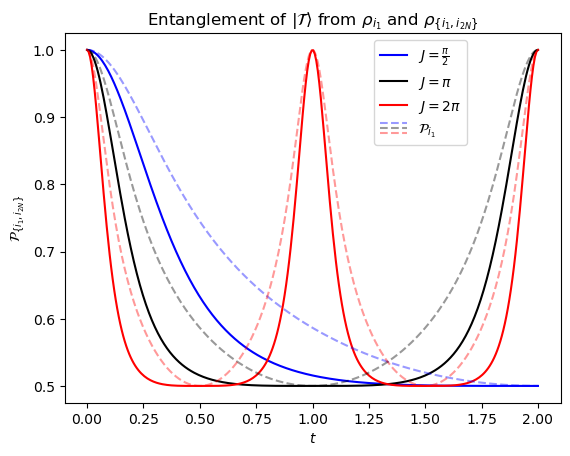

In [7]:
class TripleLineHandler(HandlerLine2D): #Custom handler to draw the triple-line icon in the legend
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        l1=Line2D([0, width], [height * 1, height * 1], color='b', linestyle='--',alpha=0.4)
        l2=Line2D([0, width], [height * 0.5, height * 0.5], color='k', linestyle='--',alpha=0.4)
        l3=Line2D([0, width], [0,0], color='r', linestyle='--',alpha=0.4)
        return [l1, l2, l3]
t1=np.linspace(0,2,300)
#t1=np.linspace(0,2,60)

plt.figure()
plt.plot(t1,np.real(VTr_rho_i1i2N_square(t1,np.pi/2)),'b-',label=r'$J=\frac{\pi}{2}$')
plt.plot(t1,np.real(VTr_rho_i1i2N_square(t1,np.pi)),'k-',label=r'$J=\pi$')
plt.plot(t1,np.real(VTr_rho_i1i2N_square(t1,2*np.pi)),'r-',label=r'$J=2\pi$')

plt.plot(t1,np.real(VTr_rho_i1_square(t1,np.pi/2)),'b--',alpha=0.4)
plt.plot(t1,np.real(VTr_rho_i1_square(t1,np.pi)),'k--',alpha=0.4)
plt.plot(t1,np.real(VTr_rho_i1_square(t1,2*np.pi)),'r--',alpha=0.4)

plt.xlabel(r"$t$")
plt.ylabel(r"$\mathcal{P}_{\left \{ i_1,i_{2N}\right \}}$")
plt.title(r"Entanglement of $|\mathcal{T}\rangle$ from $\rho_{i_1}$ and $\rho_{\{ i_1,i_{2N}\}}$")

# Legend
triple_line=Line2D([], [], color='black') 

plt.legend([*plt.gca().get_lines()[:3], triple_line], 
           [r'$J=\frac{\pi}{2}$', r'$J=\pi$', r'$J=2\pi$', r'$\mathcal{P}_{i_1}$'],
           handler_map={triple_line: TripleLineHandler()},
           loc="upper right",bbox_to_anchor=(0.825, 1))

plt.savefig("EntanglementPlot.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot 2

Generalization of the functions from [Plot 1](#plot-1-for--time-steps) for $N$ time steps and $(N-\alpha)$ legs.

$\text{Tr}\left \{ \rho_{i_1,\ldots , i_{N-\alpha}}^2\right \}$

In [8]:
def Tr_rho_i1ialpha_square(t,N,J,alpha):
    TSsys,_=TemporalStates(State,U,O,N,t,J)
    #Remove singleton dimensions manually
    TSsys=TSsys[tuple([0]+[slice(None)]*N+[0]+[slice(None)]*N+[0])]
    TSsys=TSsys/LA.norm(TSsys)
    rho=ncon([TSsys,TSsys.conj()],[-(np.linspace(1,2*N,2*N)),-(np.linspace(2*N+1,4*N,2*N))])
    rho_i1ialpha=ncon([rho],[list(range(-1,-(alpha+1),-1))+list(range(1,2*N-alpha+1))+list(range(-(alpha+1),-(2*alpha+1),-1))+list(range(1,2*N-alpha+1))])
    return ncon([rho_i1ialpha,rho_i1ialpha],list([list(range(1,(alpha+1)))+list(range(alpha+1,2*alpha+1))] + [list(range(alpha+1,2*alpha+1))+list(range(1,(alpha+1)))]))
VTr_rho_i1ialpha_square=np.vectorize(Tr_rho_i1ialpha_square)

### Plot

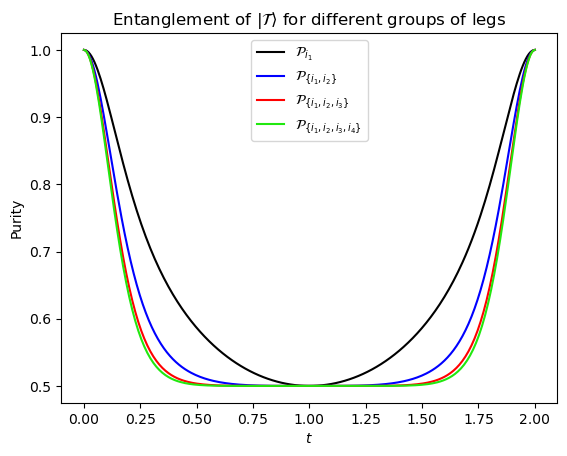

In [9]:
plt.figure()
plt.plot(t1,np.real(VTr_rho_i1ialpha_square(t1,4,np.pi,1)),color='k',label=r'$\mathcal{P}_{i_1}$')
plt.plot(t1,np.real(VTr_rho_i1ialpha_square(t1,4,np.pi,2)),color='b',label=r'$\mathcal{P}_{\left \{i_1,i_2\right \}}$')
plt.plot(t1,np.real(VTr_rho_i1ialpha_square(t1,4,np.pi,3)),color='r',label=r'$\mathcal{P}_{\left \{i_1,i_2,i_3\right \}}$')
plt.plot(t1,np.real(VTr_rho_i1ialpha_square(t1,4,np.pi,4)),color="#21e80f",label=r'$\mathcal{P}_{\left \{i_1,i_2,i_3,i_4\right \}}$')

plt.xlabel(r"$t$")
plt.ylabel("Purity")
plt.title(r"Entanglement of $|\mathcal{T}\rangle$ for different groups of legs")
plt.legend()
plt.savefig("Entanglementlegs_Plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot 3 (Appendix)

We define the function $\mathcal{P}\left ( t,N,J,\alpha\right )$

In [10]:
def AnalyticalPurity(t,N,J,alpha):
    sinplus=1+np.sin(2*J*t/N)
    sinminus=1-np.sin(2*J*t/N)
    return 1/2*(1+(np.cos(2*J*t/N))**(2*alpha)*((sinplus**(N-alpha)+sinminus**(N-alpha))/(sinplus**N+sinminus**N))**2)

### Plot

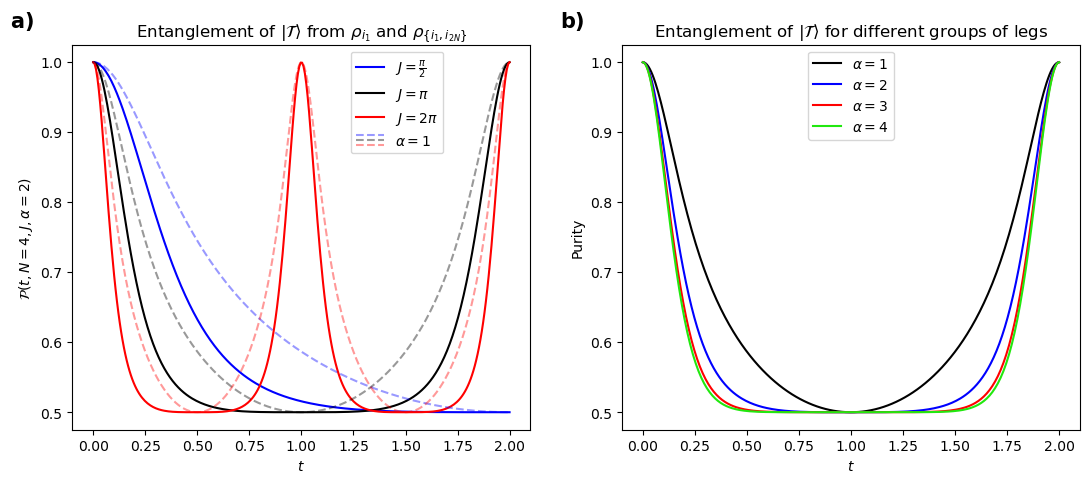

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(t1,AnalyticalPurity(t1,4,np.pi/2,2),'b-',label=r'$J=\frac{\pi}{2}$')
ax1.plot(t1,AnalyticalPurity(t1,4,np.pi,2),'k-',label=r'$J=\pi$')
ax1.plot(t1,AnalyticalPurity(t1,4,2*np.pi,2),'r-',label=r'$J=2\pi$')

ax1.plot(t1,AnalyticalPurity(t1,4,np.pi/2,1),'b--',alpha=0.4)
ax1.plot(t1,AnalyticalPurity(t1,4,np.pi,1),'k--',alpha=0.4)
ax1.plot(t1,AnalyticalPurity(t1,4,2*np.pi,1),'r--',alpha=0.4)

ax1.set(xlabel=r"$t$", ylabel=r'$\mathcal{P}\left (t,N=4,J,\alpha=2\right )$')
ax1.set_title(r"Entanglement of $|\mathcal{T}\rangle$ from $\rho_{i_1}$ and $\rho_{\{ i_1,i_{2N}\}}$")
lineas_ax1 = ax1.get_lines()[:3]
ax1.legend(
    [*lineas_ax1, triple_line],
    [
        r"$J=\frac{\pi}{2}$",
        r"$J=\pi$",
        r"$J=2\pi$",
        r"$\alpha=1$",
    ],
    handler_map={triple_line: TripleLineHandler()},
    loc="upper right",
    bbox_to_anchor=(0.825, 1),
)
ax1.text(
    -0.4,
    1.05,
    r"$\mathbf{a)}$",
    fontsize=15,
    fontweight="bold",
)


ax2.plot(t1,AnalyticalPurity(t1,4,np.pi,1),color='k',label=r'$\alpha=1$')
ax2.plot(t1,AnalyticalPurity(t1,4,np.pi,2),color='b',label=r'$\alpha=2$')
ax2.plot(t1,AnalyticalPurity(t1,4,np.pi,3),color='r',label=r'$\alpha=3$')
ax2.plot(t1,AnalyticalPurity(t1,4,np.pi,4),color="#21e80f",label=r'$\alpha=4$')

ax2.set(xlabel=r"$t$", ylabel="Purity")
ax2.set_title(r"Entanglement of $|\mathcal{T}\rangle$ for different groups of legs")
ax2.legend()
ax2.text(
    -0.4,
    1.05,
    r"$\mathbf{b)}$",
    fontsize=15,
    fontweight="bold",
)


plt.savefig("AnalyticalPurity.pdf", format="pdf", bbox_inches="tight")
plt.show()